# Session 2 — Data audit of the real PTEN data

Before summarizing anything, check that we understand the data and that it says what we think it says. These are the published, already-normalized scores from MaveDB (`urn:mavedb:00000013-a-1`), not sequencing counts.

**Aims** (from the end of the Session 2 slides):
1. Explain what each row and column means in the score tables.
2. Parse the mutation labels to identify the site, WT residue, and mutant, and verify that the listed WT residue matches the reference sequence.
3. Compare score distributions for WT, missense, nonsense, and synonymous mutations.

**Be ready to:** describe file locations with Python paths; select data subsets, find missing values, and add new columns in `pandas`.

**For each analysis, be ready to explain:** what you did (conceptually), how your code achieved it, and how you checked your assumptions.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Locate the data. This notebook assumes Jupyter is running with its working directory set to this notebook's folder (`code/my_code`), so the project root is two levels up. If a path check prints `False`, check `Path.cwd()`.

In [ ]:
project_root = Path.cwd().parent.parent
data_dir = project_root / "data" / "raw_data"

abundance_path = data_dir / "derived" / "pten-variant-abundance.csv"
scores_path = data_dir / "raw" / "mavedb-00000013-a-1-scores_raw.csv"
fasta_path = data_dir / "derived" / "pten-reference-protein.fasta"
preview_path = data_dir / "derived" / "pten-teaching-examples.csv"

abundance_path.exists(), scores_path.exists(), fasta_path.exists(), preview_path.exists()

(True, True, True, True)

The raw folder holds the unchanged published download. Never write to it. Save anything you generate somewhere else.

In [3]:
abundance = pd.read_csv(abundance_path)
scores_raw = pd.read_csv(scores_path)
preview = pd.read_csv(preview_path)

In [9]:
abundance.head

<bound method NDFrame.head of                          accession    hgvs_pro     score        sd  expts  \
0        urn:mavedb:00000013-a-1#1   p.Met1Val  1.065143  0.128434    4.0   
1        urn:mavedb:00000013-a-1#2   p.Thr2Ser  0.824359  0.428489    7.0   
2        urn:mavedb:00000013-a-1#3  p.Asn12Ile  0.298717  0.272272    7.0   
3        urn:mavedb:00000013-a-1#4  p.Arg74Val  0.855027  0.318442    6.0   
4        urn:mavedb:00000013-a-1#5  p.His75Ala  0.863776  0.223173    8.0   
...                            ...         ...       ...       ...    ...   
4404  urn:mavedb:00000013-a-1#4405  p.Arg74Asn  1.158127  0.069267    2.0   
4405  urn:mavedb:00000013-a-1#4406  p.Arg74Pro  1.059395  0.090548    2.0   
4406  urn:mavedb:00000013-a-1#4407    p.Arg74=  1.156741  0.036999    5.0   
4407  urn:mavedb:00000013-a-1#4408  p.Arg74Ser  0.868741  0.534848    5.0   
4408  urn:mavedb:00000013-a-1#4409  p.Arg74Thr  1.036819  0.145955    6.0   

            se  lower_ci  upper_ci  snv  abun

In [10]:
scores_raw.head

<bound method NDFrame.head of                          accession  hgvs_nt  hgvs_splice    hgvs_pro  \
0        urn:mavedb:00000013-a-1#1      NaN          NaN   p.Met1Val   
1        urn:mavedb:00000013-a-1#2      NaN          NaN   p.Thr2Ser   
2        urn:mavedb:00000013-a-1#3      NaN          NaN  p.Asn12Ile   
3        urn:mavedb:00000013-a-1#4      NaN          NaN  p.Arg74Val   
4        urn:mavedb:00000013-a-1#5      NaN          NaN  p.His75Ala   
...                            ...      ...          ...         ...   
4404  urn:mavedb:00000013-a-1#4405      NaN          NaN  p.Arg74Asn   
4405  urn:mavedb:00000013-a-1#4406      NaN          NaN  p.Arg74Pro   
4406  urn:mavedb:00000013-a-1#4407      NaN          NaN    p.Arg74=   
4407  urn:mavedb:00000013-a-1#4408      NaN          NaN  p.Arg74Ser   
4408  urn:mavedb:00000013-a-1#4409      NaN          NaN  p.Arg74Thr   

         score        sd  expts        se  lower_ci  upper_ci  ...  \
0     1.065143  0.128434    4.0  0.

In [11]:
preview.head

<bound method NDFrame.head of       hgvs_pro record_type     score  expts        se abundance_class_label  \
0          _wt   wild_type  1.000000    8.0  0.000000               wt_like   
1     p.Asn12=  synonymous  1.278471    3.0  0.153179               wt_like   
2   p.Tyr76Ter    nonsense  0.091532    4.0  0.061856                   low   
3   p.His75Asp    missense  1.045655    4.0  0.098263               wt_like   
4   p.Pro38Ser    missense  1.136120    4.0  0.131354               wt_like   
5  p.Cys124Ser    missense  1.137468    6.0  0.105480               wt_like   
6  p.Ser385Ala    missense  0.557348    8.0  0.070076                   low   
7   p.Asn12Ile    missense  0.298717    7.0  0.102909                   low   

                                     reason_selected  
0                        normalized reference anchor  
1                        synonymous control notation  
2  nonsense record that a weak parser may misclas...  
3                          ordinary mi

## Aim 1. Explain what each row and column means

Look at both tables side by side. Questions to answer:
- What does one **row** represent? Is that the same in both tables?
- What is the `_wt` record? What are the different `record_type` values, and how many of each are there?
- Which columns exist only in the raw table? What are they?
- Where are the values missing (`NaN`)? What could missing mean here, and could `NaN` ever be read as zero?

| column | in which table | meaning |
|---|---|---|
| `accession` | | MaveDB ID for the row |
| `hgvs_nt`, `hgvs_splice` | | nucleotide / splice labels (empty in this dataset) |
| `hgvs_pro` | |  protein change, e.g. `p.Met1Val` = position 1, Met changed to Val |
| `score` | |  abundance score averaged over replicates; WT = 1, fully degraded ≈ 0 |
| `sd`, `se` | standard error of the score |  standard deviation of the score |
| `expts` | | number of replicate experiments that measured the variant |
| `lower_ci`, `upper_ci` | | 95% confidence interval of the score |
| `score1` to `score8` | | core in each of the 8 replicates |
| `median_w_ave`, `exp1_w_ave` to `exp8_w_ave` | |  raw weighted-average fluorescence bin (0.25-1) that the score is computed from |
| `snv` | | 1 if reachable by a single nucleotide change |
| `abundance_class`, `abundance_class_label` | | 1 = low, 2 = possibly low, 3 = possibly WT-like, 4 = WT-like |
| `record_type` | | type of protein mutation|

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Aim 2. Parse mutation labels and check them against the reference

Labels look like `p.His75Asp`. Special cases exist: `_wt`, synonymous labels that end in `=`, and stop codons written `Ter`. Questions to think through first:
- What are the three pieces of a normal missense label, and where does each start and end?
- Python counts from zero but protein sites count from one. Which Python index checks the reference amino acid for site 75?
- What should happen to a stop label, a synonymous label, the `_wt` record, or an out-of-range position?
- The FASTA file uses one-letter codes and the labels use three-letter codes. How will you translate?

A FASTA file is plain text: a header line beginning with `>`, then the sequence (possibly over several lines).

### Step 1: load the reference sequence

In [13]:
lines = open(fasta_path).read().split()
ref_seq = "".join(l for l in lines if not l.startswith(">"))
ref_seq

'MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVYRNNIDDVVRFLDSKHKNHYKIYNLCAERHYDTAKFNCRVAQYPFEDHNPPQLELIKPFCEDLDQWLSEDDNHVAAIHCKAGKGRTGVMICAYLLHRGKFLKAQEALDFYGEVRTRDKKGVTIPSQRRYVYYYSYLLKNHLDYRPVALLFHKMMFETIPMFSGGTCNPQFVVCQLKVKIYSSNSGPTRREDKFMYFEFPQPLPVCGDIKVEFFHKQNKMLKKDKMFHFWVNTFFIPGPEETSEKVENGSLCDQEIDSICSIERADNDKEYLVLTLTKNDLDKANKDKANRYFSPNFKVKLYFTKTVEEPSNPEASSSTSVTPDVSDNEPDHYRYSDTTDSDPENEPFDEDQHTQITKV'

### Step 2: split each label into WT residue, site, and mutant (new columns)

In [14]:
parts = scores_raw["hgvs_pro"].str.extract(r"p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2}|=)")
scores_raw["wt"], scores_raw["pos"], scores_raw["mut"] = parts[0], parts[1].astype(float), parts[2]
scores_raw[["hgvs_pro", "wt", "pos", "mut"]].head(15)

,hgvs_pro,wt,pos,mut
0,p.Met1Val,Met,1.0,Val
1,p.Thr2Ser,Thr,2.0,Ser
2,p.Asn12Ile,Asn,12.0,Ile
3,p.Arg74Val,Arg,74.0,Val
4,p.His75Ala,His,75.0,Ala
5,p.His75Asp,His,75.0,Asp
6,p.His75Glu,His,75.0,Glu
7,p.His75Phe,His,75.0,Phe
8,p.His75Gly,His,75.0,Gly
9,p.His75Ile,His,75.0,Ile


Label each row as WT, synonymous, nonsense or missense based on the mutant.

In [16]:
def classify(row):
    if row["hgvs_pro"] == "_wt": return "WT"
    if row["mut"] == "=" or row["mut"] == row["wt"]: return "synonymous"
    if row["mut"] == "Ter": return "nonsense"
    return "missense"

scores_raw["type"] = scores_raw.apply(classify, axis=1)
scores_raw["type"].value_counts()

type
missense      4112
synonymous     156
nonsense       140
WT               1
Name: count, dtype: int64

### Step 3: compare each WT residue with the reference at that site

In [17]:
letter = {"Ala":"A","Arg":"R","Asn":"N","Asp":"D","Cys":"C","Gln":"Q","Glu":"E","Gly":"G","His":"H","Ile":"I",
      "Leu":"L","Lys":"K","Met":"M","Phe":"F","Pro":"P","Ser":"S","Thr":"T","Trp":"W","Tyr":"Y","Val":"V"}

variants = scores_raw[scores_raw["type"] != "WT"].copy()
variants["ref"] = variants["pos"].astype(int).map(lambda p: ref_seq[p - 1])
variants["match"] = variants["wt"].map(letter) == variants["ref"]
print(variants["match"].value_counts())
print("total:", variants["match"].value_counts().sum())


match
True    4408
Name: count, dtype: int64
total: 4408


### Check your work
- Test your parsing on `preview` first. It contains hand-picked edge cases.
- `manifest.json` records whether all missense reference residues match. Does your result agree?
- How many rows can your code *not* parse, and are those exactly the ones you expected?

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

### Optional: stress-test your parser
Make a copy of a small part of the score file with a few deliberately bad labels (wrong format, wrong WT residue, site out of range). Predict which ones your parser will flag and why. Then try a teammate's file.

## Aim 3. Compare score distributions by record type

Before plotting, write down what you *expect* for WT, synonymous, nonsense, and missense records.

*Your predictions:*

In [18]:
# Summary statistics of score for each record_type
scores_raw.groupby("type")["score"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
WT,1.0,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000
missense,4112.0,0.720580,0.300642,-0.223486,0.495222,0.771366,0.958364,1.462424
nonsense,140.0,0.145734,0.224835,-0.115200,-0.007010,0.064255,0.226321,1.022652
synonymous,156.0,0.963934,0.184958,0.100379,0.886546,1.003329,1.068940,1.320237


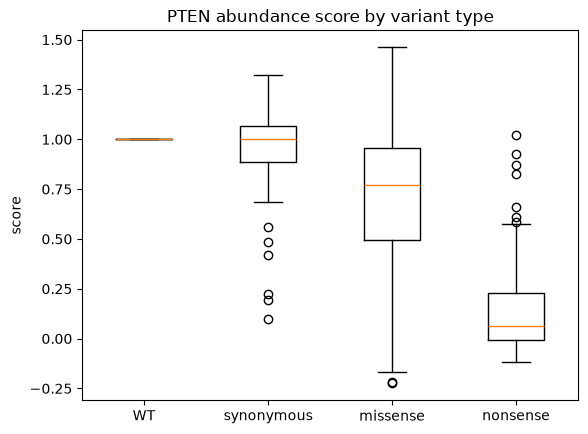

In [19]:
# Plot the distribution of score for each record_type
order = ["WT", "synonymous", "missense", "nonsense"]
plt.boxplot([scores_raw.loc[scores_raw["type"] == t, "score"] for t in order], tick_labels=order)
plt.title("PTEN abundance score by variant type")
plt.ylabel("score")
plt.show()

Questions: What do the distributions show? Do they match your predictions? What do the nonsense and synonymous groups tell you about the assay? What does the wide spread of missense scores mean? Any surprises, and how might you explain them?

*Your observations:*

**Figure checklist** (from the Session 4 slides)
- Are the labels descriptive and legible, with units where relevant?
- Is the WT reference (score = 1) visible or explained? What is "high" and what is "low"?
- Does `figsize` match the size the figure will be shown at?
- Do color and shape mean the same thing in every panel and figure?
- Is the palette right for the data: distinct colors for unordered groups, sequential for ordered amounts, diverging only around a meaningful center?
- Are colorbars labeled with visible scale marks? Do gridlines stay quiet?

**Presentation notes**
- What I did:
- How the code works:
- How I checked:

## Reproducibility record

Run this last, after restarting the kernel and running all cells.

In [ ]:
import session_info
session_info.show(dependencies=True)